# 1. Setup and import

### Import libraries and dependencies

In [17]:
!pip install pywaffle
!pip install --upgrade kagglehub -q
!pip install scikit-plot -q
!pip install phik
!pip install imblearn
!pip install category_encoders

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Import from custom modules
from src.data_loader import load_stroke_data
from src.preprocessing import clean_base_data, impute_bmi_with_rf, discretize_features, apply_smoteenn
from src.models import build_stacking_model, build_voting_model
from src.evaluation import evaluate_and_plot

# Figure styling
sns.set_style("white")
colors = ['#0D1164', '#640D5F', '#EA2264', '#F78D60']
import warnings
warnings.filterwarnings('ignore')

### Load dataset

In [19]:
# Load dataset using custom loader
df = load_stroke_data()
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


# 2. Exploratory Data Analysis

### Target Variable

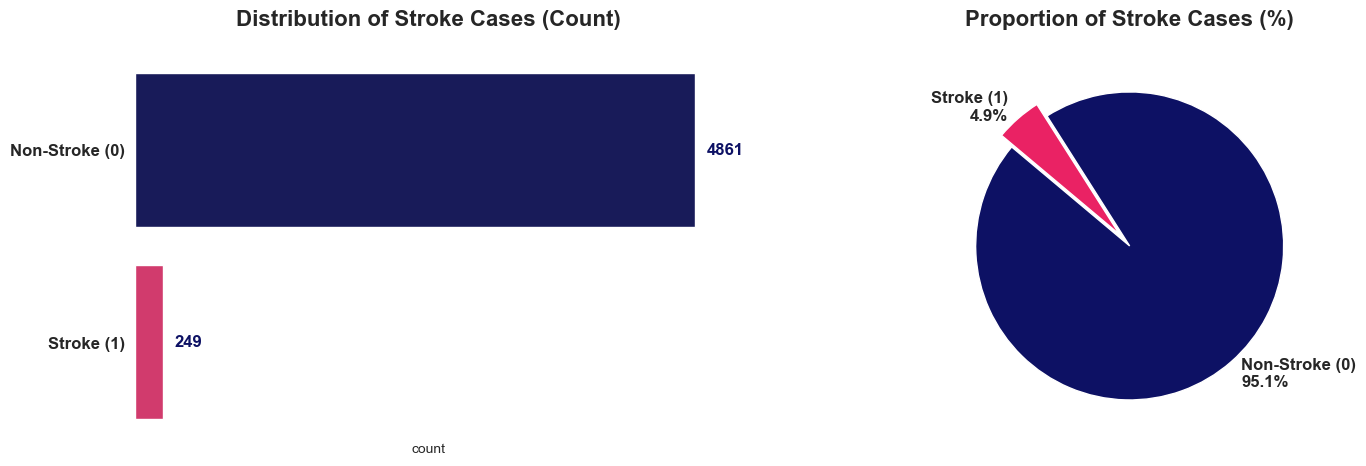

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [1.2, 1]})
plt.subplots_adjust(wspace=0.3)

# 1. Countplot
sns.countplot(data=df, y='stroke', palette=[colors[0], colors[2]], ax=ax[0])
ax[0].set_title('Distribution of Stroke Cases (Count)', fontsize=16, fontweight='bold', pad=20)
ax[0].set_yticklabels(['Non-Stroke (0)', 'Stroke (1)'], fontsize=12, fontweight='bold')
sns.despine(ax=ax[0], left=True, bottom=True)
ax[0].set_xticks([])
ax[0].set_ylabel('')

for p in ax[0].patches:
    width = p.get_width()
    ax[0].annotate(f'{int(width)}', (width + 100, p.get_y() + p.get_height() / 2.),
                   ha='left', va='center', fontsize=12, fontweight='bold', color=colors[0])

# 2. Pie Chart
stroke_counts = df['stroke'].value_counts()
total = sum(stroke_counts)
labels_with_perc = [f"Non-Stroke (0)\n{(stroke_counts[0]/total)*100:.1f}%", f"Stroke (1)\n{(stroke_counts[1]/total)*100:.1f}%"]

ax[1].pie(stroke_counts, labels=labels_with_perc, startangle=140, colors=[colors[0], colors[2]],
          explode=(0, 0.1), shadow=False, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax[1].set_title('Proportion of Stroke Cases (%)', fontsize=16, fontweight='bold', pad=20)
plt.show()

### Numerical features

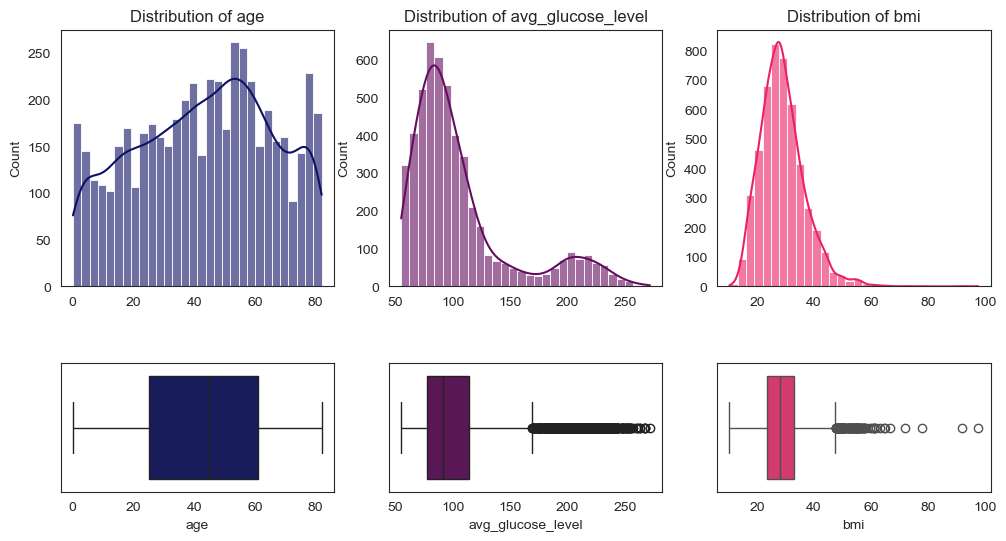

In [21]:
num_features = ['age', 'avg_glucose_level', 'bmi']

fig, axes = plt.subplots(2, 3, figsize=(12, 6), gridspec_kw={'height_ratios': [2, 1]})
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(num_features):
    # Histogram + KDE
    sns.histplot(df[col], bins=30, kde=True, ax=axes[0, i], color=colors[i], alpha=0.6)
    axes[0, i].set_title(f'Distribution of {col}', fontsize=12)
    axes[0, i].set_xlabel('')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[1, i], color=colors[i])
    axes[1, i].set_xlabel(col)

plt.show()

### Categorical features

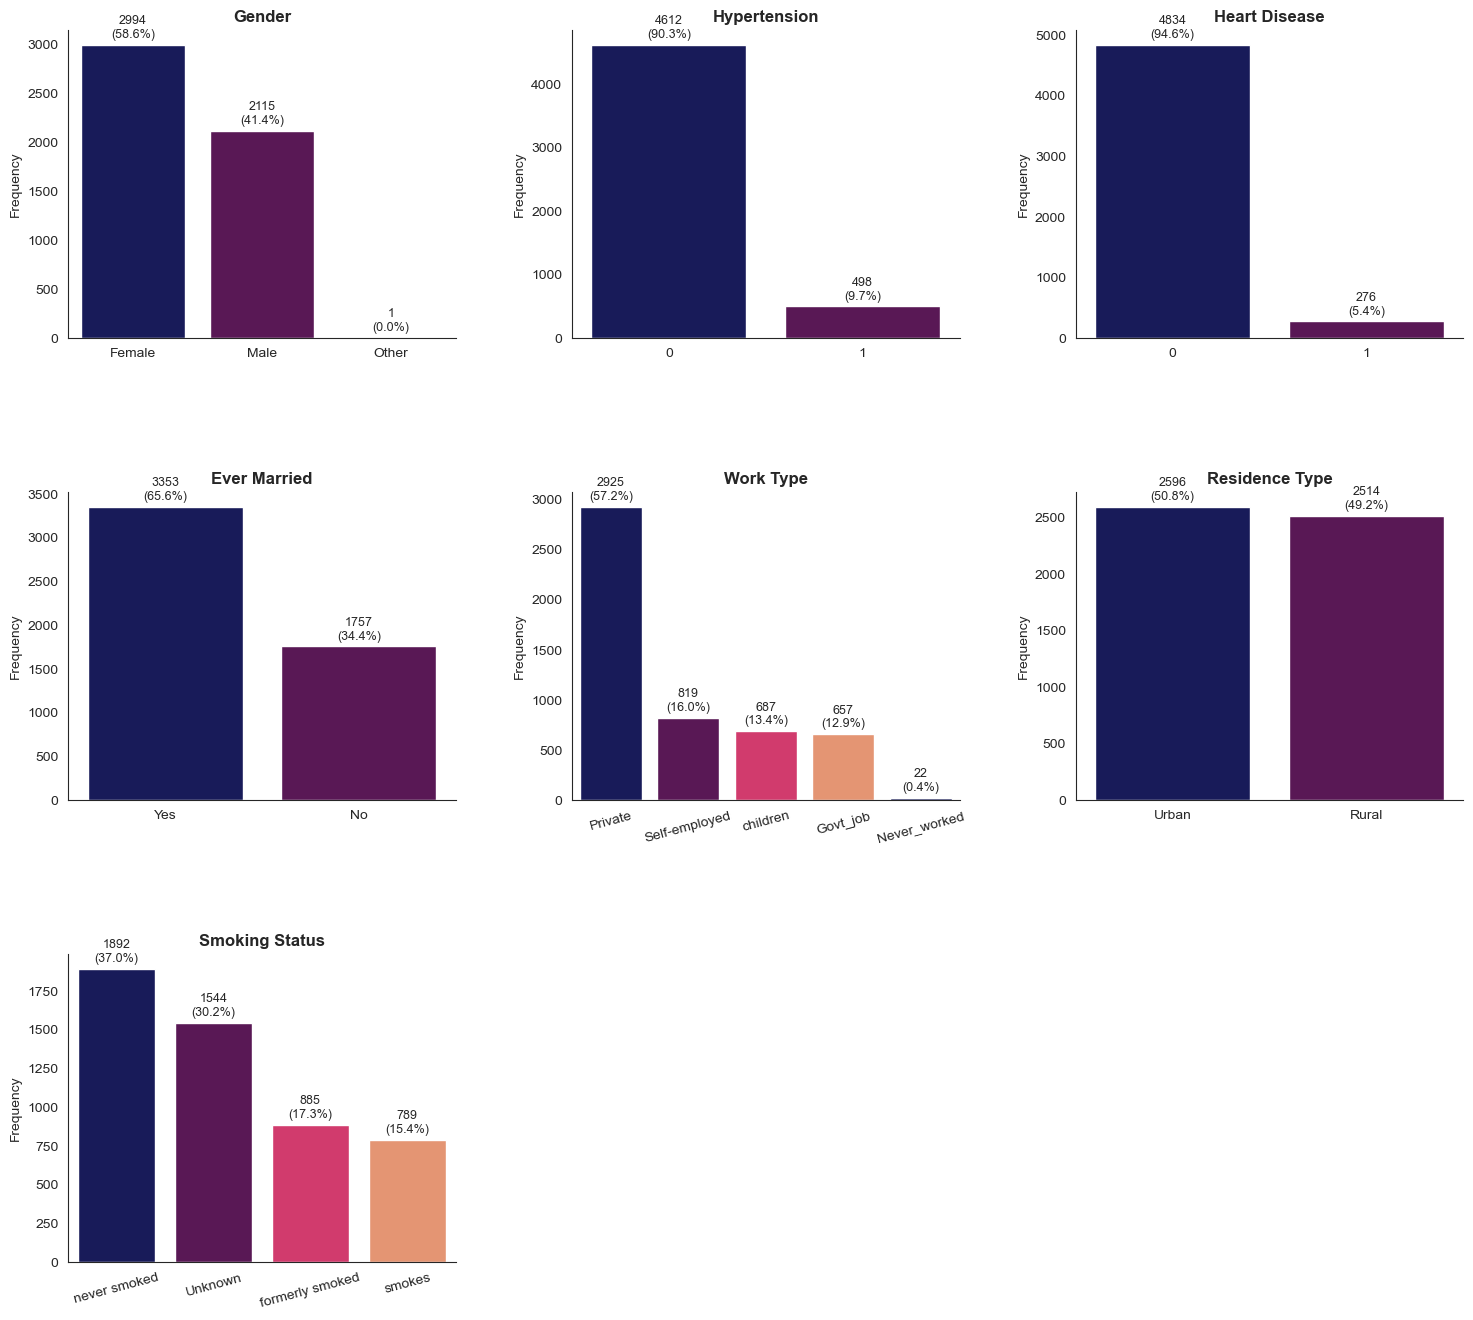

In [22]:
cat_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 16))
plt.subplots_adjust(hspace=0.5, wspace=0.3)
axes[2, 1].axis('off'); axes[2, 2].axis('off') # Hide empty subplots

for i, col in enumerate(cat_cols):
    row, col_idx = i // 3, i % 3
    curr_ax = axes[row, col_idx]
    
    counts = df[col].value_counts()
    sns.countplot(data=df, x=col, palette=colors, ax=curr_ax, order=counts.index)
    
    total_valid = len(df[col].dropna())
    for container in curr_ax.containers:
        labels = [f'{int(v.get_height())}\n({v.get_height()/total_valid*100:.1f}%)' for v in container]
        curr_ax.bar_label(container, labels=labels, padding=3, fontsize=9)
        
    curr_ax.set_title(f'{col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
    curr_ax.set_xlabel(''); curr_ax.set_ylabel('Frequency')
    if col in ['work_type', 'smoking_status']:
        curr_ax.tick_params(axis='x', rotation=15)
        
sns.despine()
plt.show()

### Correlation & Multicollinearity

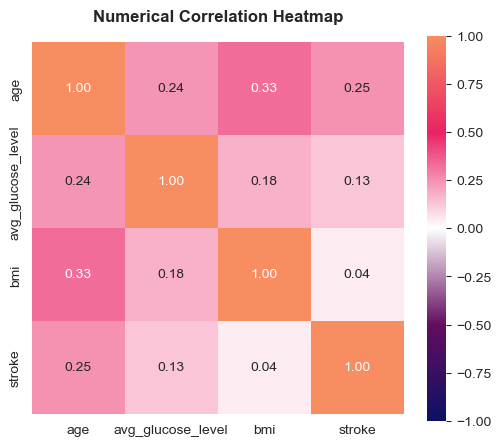


--- Multicollinearity Diagnostic Results (VIF) ---
             Feature  VIF_Score
1                age   1.167676
3                bmi   1.137775
2  avg_glucose_level   1.070868


In [23]:
# Correlation Heatmap
custom_cmap = LinearSegmentedColormap.from_list("", ['#0D1164','#640D5F','white','#EA2264','#F78D60'])
numeric_df = df[['age', 'avg_glucose_level', 'bmi', 'stroke']]

plt.figure(figsize=(6, 5))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap=custom_cmap, vmin=-1, vmax=1, square=True)
plt.title("Numerical Correlation Heatmap", fontsize=12, fontweight='bold', pad=15)
plt.show()

# VIF Calculation
vif_temp_df = df[num_features].dropna()
X_vif = add_constant(vif_temp_df)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF_Score"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("\n--- Multicollinearity Diagnostic Results (VIF) ---")
print(vif_data[vif_data['Feature'] != 'const'].sort_values(by="VIF_Score", ascending=False))

# 3. Pipeline

### Preprocessing

In [24]:
# Clean, separate target, and impute
df_clean = clean_base_data(df)
y = df_clean['stroke']
X = df_clean.drop(columns=['stroke'])

print("Imputing missing BMI values with Random Forest...")
X = impute_bmi_with_rf(X)
X = discretize_features(X)
print("Preprocessing complete.")

Imputing missing BMI values with Random Forest...
Preprocessing complete.


### Splitting, Encoding, and Balancing (SMOTEENN)

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

categorical_cols = ['gender', 'ever_married', 'Residence_type', 'work_type', 'smoking_status', 'bmi_cat', 'age_cat', 'glucose_cat']
le = LabelEncoder()
for col in categorical_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

print(f"Original Training Class Distribution: {np.bincount(y_train)}")
all_cat_cols = categorical_cols + ["hypertension", "heart_disease"]
X_train_res, y_train_res = apply_smoteenn(X_train, y_train, all_cat_cols)
print(f"Resampled Training Class Distribution: {np.bincount(y_train_res)}")

Original Training Class Distribution: [3888  199]
Resampled Training Class Distribution: [2830 3428]


### Model Training & Evaluation

With SMOTEENN data

Training Stacking Classifier...

--- STACKING CLASSIFIER RESULTS ---
Recall (Stroke): 0.52
Overall Accuracy: 0.86

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.87      0.92       972
           1       0.17      0.52      0.26        50

    accuracy                           0.86      1022
   macro avg       0.57      0.70      0.59      1022
weighted avg       0.93      0.86      0.89      1022



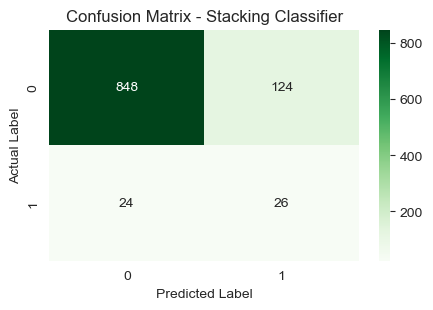

Training Voting Classifier...

--- VOTING CLASSIFIER RESULTS ---
Recall (Stroke): 0.66
Overall Accuracy: 0.80

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.80      0.88       972
           1       0.15      0.66      0.24        50

    accuracy                           0.80      1022
   macro avg       0.56      0.73      0.56      1022
weighted avg       0.94      0.80      0.85      1022



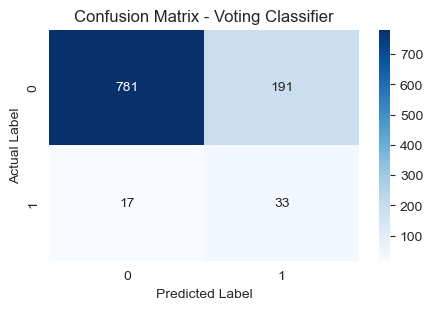

In [26]:
# Train and Evaluate Stacking Classifier
print("Training Stacking Classifier...")
stacking_model = build_stacking_model()
stacking_model.fit(X_train_res, y_train_res)
evaluate_and_plot(stacking_model, X_test, y_test, model_name="Stacking Classifier")

# Train and Evaluate Voting Classifier
print("Training Voting Classifier...")
voting_model = build_voting_model()
voting_model.fit(X_train_res, y_train_res)
evaluate_and_plot(voting_model, X_test, y_test, model_name="Voting Classifier")

### MLP Model

Number of input features: 13
Number of classes: 2
Calculated Hidden Nodes (WEKA 'a'): 7


--- MULTILAYER PERCEPTRON RESULTS ---
Recall (Stroke): 0.80
Overall Accuracy: 0.59

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.58      0.73       972
           1       0.09      0.80      0.16        50

    accuracy                           0.59      1022
   macro avg       0.54      0.69      0.44      1022
weighted avg       0.94      0.59      0.70      1022



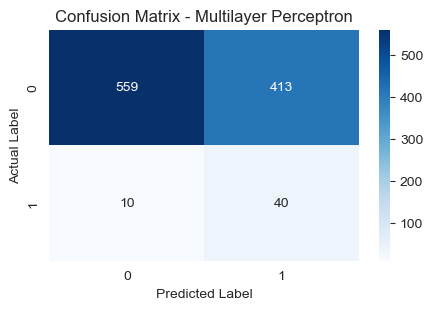

In [27]:
from src.models import build_weka_mlp

# 1. Calculate 'a' dynamically based on our SMOTEENN balanced data
n_features = X_train_res.shape[1]
n_classes = len(np.unique(y_train_res))

print(f"Number of input features: {n_features}")
print(f"Number of classes: {n_classes}")
print(f"Calculated Hidden Nodes (WEKA 'a'): {int((n_features + n_classes) / 2)}\n")

# 2. Build and Train the MLP
mlp_model = build_weka_mlp(n_features, n_classes)
mlp_model.fit(X_train_res, y_train_res)

# 3. Evaluate
evaluate_and_plot(mlp_model, X_test, y_test, model_name="Multilayer Perceptron")

### Logistic Regression

In [28]:
# Import the new functions
from src.preprocessing import apply_custom_encoding
from src.models import build_lr_pipeline
from src.evaluation import simulate_thresholds
from sklearn.metrics import accuracy_score # Ensure this is imported

X_train_enc, X_test_enc = apply_custom_encoding(X_train, X_test, y_train)

# Show the transformed data
X_train_enc.head(3)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,bmi_cat,age_cat,glucose_cat
845,0,48.0,0,0,1,0.049484,1,69.21,33.1,0.046711,3,3,0
3745,0,29.0,0,0,0,0.049484,1,84.19,21.2,0.046711,1,2,0
4184,0,35.0,0,0,1,0.049484,0,119.40,22.9,0.046711,1,2,1



--- LOGISTIC REGRESSION RESULTS ---
Recall (Stroke): 0.80
Overall Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.74      0.85       972
           1       0.14      0.80      0.24        50

    accuracy                           0.75      1022
   macro avg       0.56      0.77      0.54      1022
weighted avg       0.94      0.75      0.82      1022



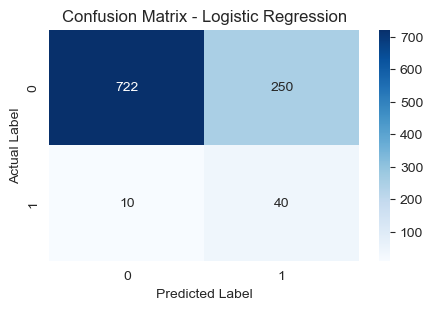

In [29]:
# 2. Build and Train the Pipeline
lr_pipeline = build_lr_pipeline()
lr_pipeline.fit(X_train_enc, y_train)

# 3. Evaluate at Default Threshold (0.5)
evaluate_and_plot(lr_pipeline, X_test_enc, y_test, model_name="Logistic Regression")

In [30]:
# 4. Extract probabilities and run the Threshold Tuning Simulation
y_probs = lr_pipeline.predict_proba(X_test_enc)[:, 1]

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5]
simulate_thresholds(y_test, y_probs, thresholds_to_test)


--- THRESHOLD TUNING SIMULATION ---
Threshold  | Recall               | False Alarms (FP)   
-------------------------------------------------------
0.10       | 0.96                 | 629                 
0.20       | 0.86                 | 513                 
0.30       | 0.84                 | 412                 
0.40       | 0.84                 | 337                 
0.50       | 0.80                 | 250                 
